Predictions: [0 1 0 1 1]
Actual labels: [0 0 0 0 0]
Test case passed successfully!
Accuracy of the KNN model on the test set: 67.39%
Accuracy for k=1: 68.70%
Accuracy for k=2: 72.61%
Accuracy for k=3: 67.39%
Accuracy for k=4: 72.17%
Accuracy for k=5: 68.70%
Accuracy for k=6: 70.00%
Accuracy for k=7: 69.13%
Accuracy for k=8: 71.30%
Accuracy for k=9: 70.00%
Accuracy for k=10: 71.74%
Accuracy for k=11: 73.04%
Accuracy for k=12: 73.91%
Accuracy for k=13: 74.35%
Accuracy for k=14: 72.61%
Accuracy for k=15: 73.91%
Accuracy for k=16: 73.48%
Accuracy for k=17: 72.61%
Accuracy for k=18: 71.30%
Accuracy for k=19: 72.17%
Accuracy for k=20: 70.87%


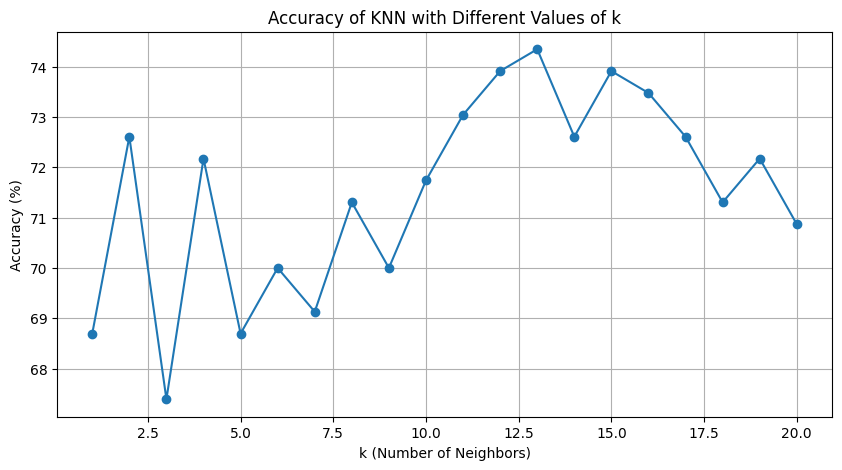

Experiment completed. Check the plot for the accuracy trend.


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = pd.read_csv("diabetes_.csv")

missing_info = data.isnull().sum() / len(data) * 100

for col in data.columns:
    missing_percent = missing_info[col]

    if missing_percent == 0:
        continue
    elif missing_percent < 10:
        data = data.dropna(subset=[col])
    else:
        if data[col].dtype in ['int64', 'float64']:
            data[col].fillna(data[col].median(), inplace=True)
        else:
            data[col].fillna(data[col].mode()[0], inplace=True)

X = data.drop(columns=['Outcome'])
y = data['Outcome'].values

def training_testing_data(X, y, test_size=0.3, random_seed=42):
    np.random.seed(random_seed)
    indices = np.arange(len(X))
    np.random.shuffle(indices)

    test_split_size = int(len(X) * test_size)
    test_indices = indices[:test_split_size]
    train_indices = indices[test_split_size:]

    X_train = X.iloc[train_indices].values
    X_test = X.iloc[test_indices].values
    y_train = y[train_indices]
    y_test = y[test_indices]

    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = training_testing_data(X, y, test_size=0.3)

def euclidean_distance(point1, point2):
    if point1.shape != point2.shape:
        raise ValueError("Dimension mismatch")
    return np.sqrt(np.sum((point1 - point2) ** 2))

def knn_predict_single(query, X_train, y_train, k=3):
    distances = [euclidean_distance(query, x) for x in X_train]
    sorted_indices = np.argsort(distances)
    nearest_indices = sorted_indices[:k]
    nearest_labels = y_train[nearest_indices]
    return np.bincount(nearest_labels).argmax()

def knn_predict(X_test, X_train, y_train, k=3):
    predictions = [knn_predict_single(x, X_train, y_train, k) for x in X_test]
    return np.array(predictions)

try:
    X_test_sample = X_test[:5]
    y_test_sample = y_test[:5]
    predictions = knn_predict(X_test_sample, X_train, y_train, k=3)

    print("Predictions:", predictions)
    print("Actual labels:", y_test_sample)

    assert predictions.shape == y_test_sample.shape
    print("Test case passed successfully!")
except AssertionError as ae:
    print(f"AssertionError: {ae}")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

def compute_accuracy(y_true, y_pred):
    correct_predictions = np.sum(y_true == y_pred)
    total_predictions = len(y_true)
    return (correct_predictions / total_predictions) * 100

try:
    predictions = knn_predict(X_test, X_train, y_train, k=3)
    accuracy = compute_accuracy(y_test, predictions)
    print(f"Accuracy of the KNN model on the test set: {accuracy:.2f}%")
except Exception as e:
    print(f"An unexpected error occurred during prediction or accuracy computation: {e}")

def experiment_knn_k_values(X_train, y_train, X_test, y_test, k_values):
    accuracies = {}
    for k in k_values:
        predictions = knn_predict(X_test, X_train, y_train, k=k)
        accuracy = compute_accuracy(y_test, predictions)
        accuracies[k] = accuracy
        print(f"Accuracy for k={k}: {accuracy:.2f}%")
    plt.figure(figsize=(10, 5))
    plt.plot(k_values, list(accuracies.values()), marker='o')
    plt.xlabel('k (Number of Neighbors)')
    plt.ylabel('Accuracy (%)')
    plt.title("Accuracy of KNN with Different Values of k")
    plt.grid(True)
    plt.show()

    return accuracies
    # Define the range of k values to experiment with
k_values = range(1, 21) # You can adjust this range as needed
# Run the experiment
try:
  accuracies = experiment_knn_k_values(X_train, y_train, X_test, y_test, k_values)
  print("Experiment completed. Check the plot for the accuracy trend.")
except Exception as e:
  print(f"An unexpected error occurred during the experiment: {e}")